In [ ]:
#1.Q: Train Logistic Regression, Decision Tree, and Random Forest on the fruits.csv dataset and compare accuracy.
# Weight (grams)    Size (cm)	  Color Score   Fruit Type
# 150               7.5           0.8          Apple
# 170               8.0           0.7          Apple
# 200               9.0           0.6          Orange
# 210               9.5           0.5          Orange
# 180               8.5           0.65         Apple

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = {
    "Weight (grams)": [150, 170, 200, 210, 180],
    "Size (cm)": [7.5, 8.0, 9.0, 9.5, 8.5],
    "Color Score": [0.8, 0.7, 0.6, 0.5, 0.65],
    "Fruit Type": ["Apple", "Apple", "Orange", "Orange", "Apple"]
}

data_df = pd.DataFrame(data)
data_df = pd.get_dummies(data_df, drop_first=True)


X = data_df.iloc[:, :-1]
y = data_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'{name} Accuracy: {accuracy:.2f}')


[9.999999999999998, 1.4285714285714284, 0.5714285714285713, 0.28571428571428564]


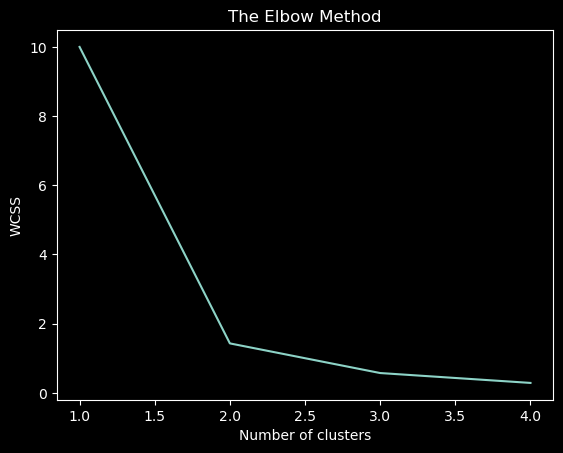

   Annual_Income  Spending_Score  KMeansCluster  DBSCANCluster  \
0             50              40              1             -1   
1             55              35              1             -1   
2             60              70              0             -1   
3             65              75              0             -1   
4             70              80              0             -1   

   AgglomerativeCluster  
0                     1  
1                     1  
2                     0  
3                     0  
4                     0  
KMeans Cluster Counts: {0: 3, 1: 2}
DBSCAN Cluster Counts: {-1: 5}
Agglomerative Cluster Counts: {0: 3, 1: 2}


In [43]:
#2.Apply K-Means, DBSCAN, and Agglomerative Clustering on the following dataset and print cluster counts.
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

data = {
    "Annual_Income": [50, 55, 60, 65, 70],
    "Spending_Score": [40, 35, 70, 75, 80]
}

data_df = pd.DataFrame(data)

scaler = StandardScaler()
X = scaler.fit_transform(data_df)
X = pd.DataFrame(X, columns=["Annual_Income", "Spending_Score"])

# -----------------------KMEANS METHOD------------------------
wcss=[]
for i in range(1,5):
    model = KMeans(n_clusters=i, n_init='auto', random_state = 25)
    model.fit(X)
    wcss.append( model.inertia_)
print( wcss)
    
plt.plot(range(1, 5), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

k=2 # Based on Elbow method
model = KMeans(n_clusters=k, n_init='auto', random_state = 25)
model.fit(X)
labels = model.labels_
data_df['KMeansCluster'] = labels

# ------------------------DBSCAN METHOD------------------------
model = DBSCAN(eps=0.5, min_samples=2)
model.fit(X)
labels = model.labels_
data_df['DBSCANCluster'] = labels

# -----------------------AGGLOMERATIVE METHOD------------------------
model = AgglomerativeClustering(n_clusters=2)
model.fit(X)
labels = model.labels_
data_df['AgglomerativeCluster'] = labels

print(data_df)

# Calculate cluster counts
kmeans_cluster_counts = data_df.groupby('KMeansCluster')['KMeansCluster'].count()
dbscan_cluster_counts = data_df.groupby('DBSCANCluster')['DBSCANCluster'].count()
agglomerative_cluster_counts = data_df.groupby('AgglomerativeCluster')['AgglomerativeCluster'].count()
print('KMeans Cluster Counts:', kmeans_cluster_counts.to_dict())
print('DBSCAN Cluster Counts:', dbscan_cluster_counts.to_dict())
print('Agglomerative Cluster Counts:', agglomerative_cluster_counts.to_dict())


In [44]:
#3.
#The dataset below contains information about houses. 
#Train and compare three regression models (Linear Regression, Decision Tree, Random Forest) to predict Price.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

data = {
    "Area (sqft)": [850, 900, 1200, 1500, 1750, 2000, 2500, 2750, 3000],
    "Bedrooms": [2, 2, 3, 3, 4, 4, 4, 5, 5],
    "Age (years)": [5, 10, 8, 15, 20, 18, 12, 30, 25],
    "Price": [150000, 170000, 210000, 250000, 275000, 300000, 350000, 375000, 400000]
}

data_df = pd.DataFrame(data)
X = data_df.iloc[:, :-1]
y = data_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2score = r2_score(y_test, y_pred)
    print(f"{name} R2 Score: {r2score:.2f}")


Linear Regression R2 Score: 0.89
Decision Tree R2 Score: -0.38
Random Forest R2 Score: -1.85


In [45]:
#4.Decision Tree, Random Forest) to predict if a loan will be approved (1) or rejected (0).
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = {
    "Credit Score": [600, 650, 700, 750, 800, 850, 500, 550, 580],
    "Income ($)": [40000, 50000, 60000, 80000, 100000, 120000, 25000, 30000, 35000],
    "Loan Amount": [20000, 25000, 30000, 35000, 40000, 45000, 15000, 20000, 22000],
    "Approval": [0, 0, 1, 1, 1, 1, 0, 0, 0]
}

data_df = pd.DataFrame(data)

X = data_df.iloc[:, :-1]
y = data_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'{name} Accuracy: {accuracy:.2f}')


Decision Tree Accuracy: 1.00
Random Forest Accuracy: 1.00


In [46]:
#5.Classify transactions as fraudulent (1) or non-fraudulent (0) using three classification models (SVM, Logistic Regression, Random Forest).

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = {
    "Transaction Amount ($)": [10, 500, 3000, 50, 7000, 25000, 100, 50000, 200],
    "Transaction Type": [0, 1, 1, 0, 1, 1, 0, 1, 0],  # 0: Normal, 1: High-Risk
    "Fraud": [0, 0, 1, 0, 1, 1, 0, 1, 0]
}

data_df = pd.DataFrame(data)

X = data_df.iloc[:, :-1]
y = data_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=25)

models = {
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'{name} Accuracy: {accuracy:.2f}')


SVM Accuracy: 0.00
Logistic Regression Accuracy: 1.00
Random Forest Accuracy: 0.67
